In [1]:
# Librerías base
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Modelos
from sklearn.linear_model import LogisticRegression

In [2]:
# Cargar dataset
data_path = "../data/raw/MalBehavD-V1-dataset.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2570, 177)


,sha256,labels,0,1,2,3,4,5,6,7,...,Unnamed: 167,Unnamed: 168,Unnamed: 169,Unnamed: 170,Unnamed: 171,Unnamed: 172,Unnamed: 173,Unnamed: 174,Unnamed: 175,Unnamed: 176
0,5c18291c481a192ed5003084dab2d8a117fd3736359218...,0,LdrUnloadDll,CoUninitialize,NtQueryKey,NtDuplicateObject,GetShortPathNameW,GetSystemInfo,IsDebuggerPresent,GetSystemWindowsDirectoryW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4683faf3da550ffb594cf5513c4cbb34f64df85f27fd1c...,0,NtOpenMutant,GetForegroundWindow,NtQueryKey,DrawTextExW,NtSetInformationFile,RegQueryValueExA,LdrGetProcedureAddress,CoUninitialize,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9a0aea1c7290031d7c3429d0e921f107282cc6eab854ee...,0,GetForegroundWindow,DrawTextExW,GetSystemInfo,IsDebuggerPresent,GetSystemWindowsDirectoryW,NtQueryValueKey,RegCloseKey,GetFileAttributesW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,e0f3e4d5f50afd9c31e51dd9941c5a52d57c7c524f5d11...,0,NtQueryValueKey,LdrUnloadDll,GlobalMemoryStatus,WriteConsoleA,NtOpenKey,LdrGetProcedureAddress,NtTerminateProcess,NtClose,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ec2b6d29992f13e74015ff0b129150b4afae15c593e4b7...,0,LdrUnloadDll,GetSystemTimeAsFileTime,NtOpenKey,WSAStartup,SetUnhandledExceptionFilter,NtTerminateProcess,NtClose,NtAllocateVirtualMemory,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Información del dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2570 entries, 0 to 2569
Columns: 177 entries, sha256 to Unnamed: 176
dtypes: int64(1), object(176)
memory usage: 3.5+ MB


In [4]:
# Distribución de clases

df["labels"].value_counts()

labels
0    1285
1    1285
Name: count, dtype: int64

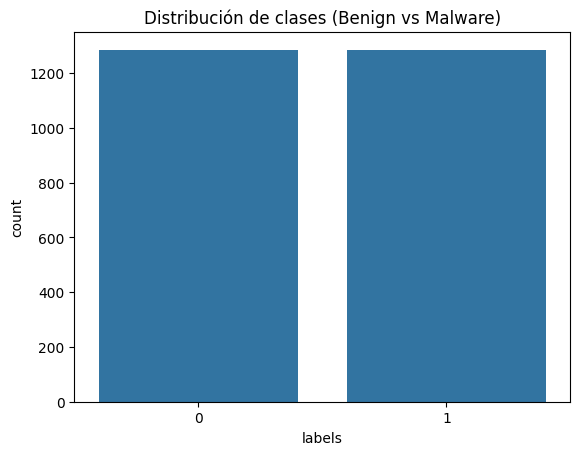

In [5]:
# Visualizar distribución

sns.countplot(x="labels", data=df)
plt.title("Distribución de clases (Benign vs Malware)")
plt.show()

In [6]:
# Convertir columnas de APIs en una secuencia de texto

api_columns = df.columns[2:]

df["sequence"] = df[api_columns].apply(
    lambda row: " ".join(row.dropna().astype(str)),
    axis=1
)

df[["labels", "sequence"]].head()

,labels,sequence
0,0,LdrUnloadDll CoUninitialize NtQueryKey NtDupli...
1,0,NtOpenMutant GetForegroundWindow NtQueryKey Dr...
2,0,GetForegroundWindow DrawTextExW GetSystemInfo ...
3,0,NtQueryValueKey LdrUnloadDll GlobalMemoryStatu...
4,0,LdrUnloadDll GetSystemTimeAsFileTime NtOpenKey...


In [7]:
# Dividir dataset en entrenamiento y prueba

X = df["sequence"]
y = df["labels"]

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 1799
Test size: 771


In [8]:
# Generar el dataset procesado

processed_path = "../data/processed/malbehav_sequences.csv"

df_processed = df[["labels", "sequence"]]

df_processed.to_csv(processed_path, index=False)

print("Processed dataset saved.")

Processed dataset saved.


In [9]:
# Guardar los splits

train_df = pd.DataFrame({
    "sequence": X_train,
    "labels": y_train
})

test_df = pd.DataFrame({
    "sequence": X_test,
    "labels": y_test
})

train_df.to_csv("../data/splits/train.csv", index=False)
test_df.to_csv("../data/splits/test.csv", index=False)

print("Train/Test splits saved.")

Train/Test splits saved.


In [10]:
import os
import joblib

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

In [11]:
# inputs

X_train_text = X_train
X_test_text = X_test

X_train_text = pd.Series(X_train_text).fillna("").astype(str)
X_test_text  = pd.Series(X_test_text).fillna("").astype(str)

y_train = pd.Series(y_train)
y_test = pd.Series(y_test)

In [12]:
# ENCODE LABELS
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Clases:", list(le.classes_))
# Idealmente: ['benign', 'malware'] o similar

Clases: [np.int64(0), np.int64(1)]


In [13]:
# creación de features

from sklearn.feature_extraction.text import TfidfVectorizer

X_train = pd.Series(X_train).fillna("").astype(str)
X_test  = pd.Series(X_test).fillna("").astype(str)

vectorizer = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Vectorized train shape:", X_train_vec.shape)
print("Vectorized test shape :", X_test_vec.shape)

Vectorized train shape: (1799, 4131)
Vectorized test shape : (771, 4131)


In [14]:
# Baseline: Logistic Regression

log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear",        # robusto para sparse y binario
    random_state=42
)

log_reg.fit(X_train_vec, y_train_enc)

y_pred = log_reg.predict(X_test_vec)
y_proba = log_reg.predict_proba(X_test_vec)[:, 1]  # prob clase positiva

In [15]:
# Métricas hold-out (test)

acc = accuracy_score(y_test_enc, y_pred)
prec = precision_score(y_test_enc, y_pred, average="binary", zero_division=0)
rec = recall_score(y_test_enc, y_pred, average="binary", zero_division=0)
f1 = f1_score(y_test_enc, y_pred, average="binary", zero_division=0)
roc_auc = roc_auc_score(y_test_enc, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}\n")

print("Classification Report:")
print(classification_report(
    y_test_enc, y_pred,
    target_names=[str(c) for c in le.classes_],
    zero_division=0
))

Accuracy : 0.9585
Precision: 0.9682
Recall   : 0.9481
F1-score : 0.9580
ROC-AUC  : 0.9833

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       386
           1       0.97      0.95      0.96       385

    accuracy                           0.96       771
   macro avg       0.96      0.96      0.96       771
weighted avg       0.96      0.96      0.96       771



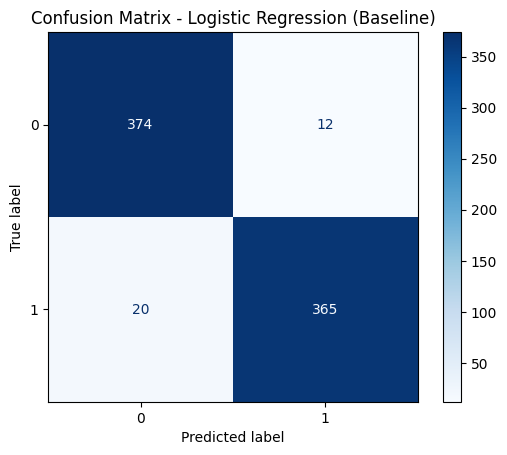

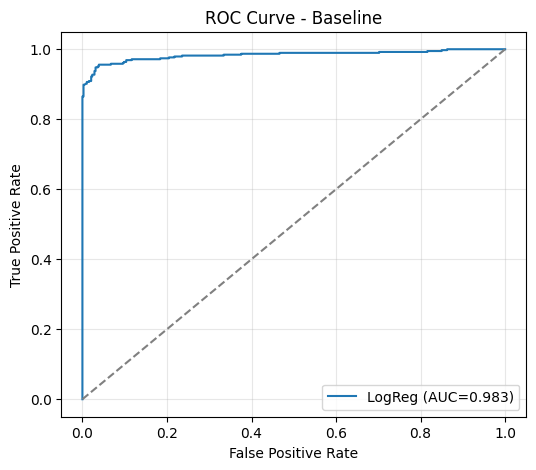

In [16]:
# Confusion Matrix + ROC Curve

cm = confusion_matrix(y_test_enc, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression (Baseline)")
plt.show()

fpr, tpr, _ = roc_curve(y_test_enc, y_proba)
roc_auc_curve = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"LogReg (AUC={roc_auc_curve:.3f})")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [17]:
# Validación cruzada K=10 (sobre train)

# Pipeline para evitar data leakage en CV
cv_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_pipeline, X_train_text, y_train_enc, cv=skf, scoring="accuracy")

print(f"CV Accuracy (10-fold): mean={cv_scores.mean():.4f}, std={cv_scores.std():.4f}")
print("Fold scores:", np.round(cv_scores, 4))

CV Accuracy (10-fold): mean=0.9505, std=0.0167
Fold scores: [0.9778 0.9333 0.9611 0.9611 0.9333 0.9389 0.9222 0.9556 0.9556 0.9665]


In [18]:
# Guardar resultados y modelo

from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

results_dir = project_root / "results"
models_dir = project_root / "models"

results_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)


baseline_results = pd.DataFrame([{
    "model": "Logistic Regression (TF-IDF baseline)",
    "accuracy_test": acc,
    "precision_test": prec,
    "recall_test": rec,
    "f1_test": f1,
    "roc_auc_test": roc_auc,
    "cv10_acc_mean": cv_scores.mean(),
    "cv10_acc_std": cv_scores.std(),
    "n_features": X_train_vec.shape[1]
}])

baseline_csv_path = results_dir / "baseline_results.csv"
baseline_results.to_csv(baseline_csv_path, index=False)

model_path = models_dir / "logistic_model.pkl"
joblib.dump({
    "vectorizer": vectorizer,
    "label_encoder": le,
    "model": log_reg
}, model_path)
print(f"Guardado: {baseline_csv_path.relative_to(project_root)}")
print(f"Guardado: {model_path.relative_to(project_root)}")

Guardado: results\baseline_results.csv
Guardado: models\logistic_model.pkl


### Model 2 - Gemini Embeddings + MLP

This section adds a second malware classifier using Gemini embeddings and a neural network, while keeping Model 1 unchanged.

Before running these cells:
- Install `google-genai` and `tqdm` if needed.
- Set `GEMINI_API_KEY` or `GOOGLE_API_KEY` in your environment.
- Internet access is required to generate embeddings.


In [19]:
%pip install -U google-genai tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
echo $env:GEMINI_API_KEY

$env:GEMINI_API_KEY


In [1]:
# Model 2 setup
# If needed inside Jupyter, uncomment the next line:
# %pip install -qU google-genai tqdm

import json
import os
import random
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from google import genai
from google.genai import types

from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [2]:
def get_project_root_m2() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "data").exists():
        return cwd
    if (cwd.parent / "data").exists():
        return cwd.parent
    for parent in cwd.parents:
        if (parent / "data").exists():
            return parent
    raise RuntimeError(f"Could not locate project root from cwd={cwd}")


project_root_m2 = get_project_root_m2()
data_splits_m2 = project_root_m2 / "data" / "splits"
data_processed_m2 = project_root_m2 / "data" / "processed"
results_dir_m2 = project_root_m2 / "results"
models_dir_m2 = project_root_m2 / "models"

data_processed_m2.mkdir(parents=True, exist_ok=True)
results_dir_m2.mkdir(parents=True, exist_ok=True)
models_dir_m2.mkdir(parents=True, exist_ok=True)

train_path_m2 = data_splits_m2 / "train.csv"
test_path_m2 = data_splits_m2 / "test.csv"

train_df_m2 = pd.read_csv(train_path_m2)
test_df_m2 = pd.read_csv(test_path_m2)

assert {"sequence", "labels"}.issubset(train_df_m2.columns), train_df_m2.columns
assert {"sequence", "labels"}.issubset(test_df_m2.columns), test_df_m2.columns

X_train_text_m2 = train_df_m2["sequence"].fillna("").astype(str).tolist()
y_train_m2 = train_df_m2["labels"].astype(int).to_numpy()

X_test_text_m2 = test_df_m2["sequence"].fillna("").astype(str).tolist()
y_test_m2 = test_df_m2["labels"].astype(int).to_numpy()

print("Project root:", project_root_m2)
print("Train shape:", train_df_m2.shape)
print("Test shape :", test_df_m2.shape)


Project root: C:\Users\Andy Ortega\Progras\Security Data Science\Lab02_SDS
Train shape: (1799, 2)
Test shape : (771, 2)


In [ ]:
import os
os.environ["GEMINI_API_KEY"] = "GEMINI_API_KEY"

In [4]:
api_key_m2 = os.getenv("GEMINI_API_KEY") or os.getenv("GOOGLE_API_KEY")
if not api_key_m2:
    raise RuntimeError(
        "Missing GEMINI_API_KEY or GOOGLE_API_KEY. Set one before running Model 2."
    )

client_m2 = genai.Client(api_key=api_key_m2)
print("Gemini client ready.")

Gemini client ready.


In [5]:
EMBED_MODEL_M2 = "gemini-embedding-001"
EMBED_TASK_TYPE_M2 = "CLASSIFICATION"
EMBED_DIM_M2 = 768
MAX_INPUT_TOKENS_M2 = 2048

def sample_token_counts_m2(texts, sample_size=20, seed=42):
    rng = random.Random(seed)
    if not texts:
        return []
    sample_size = min(sample_size, len(texts))
    sample = [texts[rng.randrange(len(texts))] for _ in range(sample_size)]
    counts = []
    for text in sample:
        resp = client_m2.models.count_tokens(model=EMBED_MODEL_M2, contents=text)
        total_tokens = getattr(resp, "total_tokens", None)
        if total_tokens is None:
            raise RuntimeError("Could not read total_tokens from count_tokens response.")
        counts.append(int(total_tokens))
    return counts


try:
    token_counts_m2 = sample_token_counts_m2(X_train_text_m2, sample_size=20)
    print("Token sample stats -> min:", min(token_counts_m2), "mean:", round(sum(token_counts_m2) / len(token_counts_m2), 2), "max:", max(token_counts_m2))
except Exception as exc:
    print("Token counting skipped:", repr(exc))


Token sample stats -> min: 43 mean: 131.25 max: 463


In [6]:
def normalize_whitespace_m2(text):
    return " ".join(text.strip().split())


def truncate_by_words_m2(text, max_words=800):
    parts = text.split()
    if len(parts) <= max_words:
        return text
    return " ".join(parts[:max_words])


def is_retriable_exception_m2(exc):
    code = getattr(exc, "status_code", None) or getattr(exc, "code", None)
    if code in {408, 429, 500, 502, 503, 504}:
        return True
    message = str(exc).lower()
    retriable_markers = [
        "429",
        "rate limit",
        "resource exhausted",
        "timeout",
        "timed out",
        "503",
        "502",
        "504",
        "connection reset",
    ]
    return any(marker in message for marker in retriable_markers)


def extract_retry_delay_seconds_m2(exc, default_sleep_s):
    import re

    message = str(exc)
    patterns = [
        r"retryDelay': '(\\d+)s'",
        r"Please retry in ([0-9.]+)s",
    ]
    for pattern in patterns:
        match = re.search(pattern, message)
        if match:
            return max(default_sleep_s, float(match.group(1)))
    return default_sleep_s


def embed_one_batch_m2(text_batch):
    response = client_m2.models.embed_content(
        model=EMBED_MODEL_M2,
        contents=text_batch,
        config=types.EmbedContentConfig(
            task_type=EMBED_TASK_TYPE_M2,
            output_dimensionality=EMBED_DIM_M2,
        ),
    )
    return np.asarray([item.values for item in response.embeddings], dtype=np.float32)


TARGET_EMBED_REQUESTS_PER_MINUTE_M2 = 90


train_emb_path_m2 = data_processed_m2 / f"emb_{EMBED_MODEL_M2}_{EMBED_TASK_TYPE_M2}_dim{EMBED_DIM_M2}_train.npz"
test_emb_path_m2 = data_processed_m2 / f"emb_{EMBED_MODEL_M2}_{EMBED_TASK_TYPE_M2}_dim{EMBED_DIM_M2}_test.npz"


In [7]:
def save_embedding_cache_m2(path, X, y, metadata):
    np.savez_compressed(
        path,
        X=X.astype(np.float32),
        y=y.astype(np.int32),
        metadata=np.array(json.dumps(metadata)),
    )


def load_embedding_cache_m2(path):
    cache = np.load(path, allow_pickle=False)
    X = cache["X"].astype(np.float32)
    y = cache["y"].astype(np.int32)
    metadata = json.loads(str(cache["metadata"]))
    return X, y, metadata


def build_embedding_metadata_m2(split_name, total_count):
    return {
        "model": EMBED_MODEL_M2,
        "task_type": EMBED_TASK_TYPE_M2,
        "output_dimensionality": EMBED_DIM_M2,
        "split": split_name,
        "total_count": int(total_count),
        "completed_count": 0,
        "is_complete": False,
        "created_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
        "updated_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    }


def generate_embeddings_with_resume_m2(texts, y, cache_path, split_name, batch_size=32, max_attempts=10, base_sleep_s=2.0):
    cleaned = [truncate_by_words_m2(normalize_whitespace_m2(text)) for text in texts]
    total_count = len(cleaned)
    y_array = np.asarray(y, dtype=np.int32)

    if cache_path.exists():
        X_cache, y_cache, metadata = load_embedding_cache_m2(cache_path)
        valid_cache = (
            X_cache.shape == (total_count, EMBED_DIM_M2)
            and y_cache.shape == y_array.shape
            and np.array_equal(y_cache, y_array)
        )
        if valid_cache:
            completed_count = int(metadata.get("completed_count", 0))
            completed_count = max(0, min(completed_count, total_count))
            if metadata.get("is_complete") and completed_count == total_count:
                print(f"Loaded complete cached embeddings for {split_name}.")
                return X_cache, y_cache, metadata
            print(f"Resuming {split_name} embeddings from index {completed_count} of {total_count}.")
        else:
            print(f"Ignoring incompatible cache for {split_name}; rebuilding from scratch.")
            X_cache = np.zeros((total_count, EMBED_DIM_M2), dtype=np.float32)
            y_cache = y_array
            metadata = build_embedding_metadata_m2(split_name, total_count)
            completed_count = 0
            save_embedding_cache_m2(cache_path, X_cache, y_cache, metadata)
    else:
        X_cache = np.zeros((total_count, EMBED_DIM_M2), dtype=np.float32)
        y_cache = y_array
        metadata = build_embedding_metadata_m2(split_name, total_count)
        completed_count = 0
        save_embedding_cache_m2(cache_path, X_cache, y_cache, metadata)

    progress = tqdm(total=total_count, initial=completed_count, desc=f"Embedding {split_name}", unit="text")
    start_idx = completed_count

    while start_idx < total_count:
        batch = cleaned[start_idx:start_idx + batch_size]
        attempt = 1
        while True:
            try:
                batch_embeddings = embed_one_batch_m2(batch)
                if batch_embeddings.shape[0] != len(batch):
                    raise RuntimeError(
                        f"Expected {len(batch)} embeddings but got {batch_embeddings.shape[0]}"
                    )

                X_cache[start_idx:start_idx + len(batch), :] = batch_embeddings
                start_idx += len(batch)
                metadata["completed_count"] = int(start_idx)
                metadata["is_complete"] = bool(start_idx >= total_count)
                metadata["updated_utc"] = time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())
                save_embedding_cache_m2(cache_path, X_cache, y_cache, metadata)
                progress.update(len(batch))

                throttle_sleep = 60.0 * len(batch) / TARGET_EMBED_REQUESTS_PER_MINUTE_M2
                if start_idx < total_count:
                    print(f"[throttle] split={split_name}, sleeping {throttle_sleep:.1f}s to stay under free-tier quota.")
                    time.sleep(throttle_sleep)
                break
            except Exception as exc:
                if not is_retriable_exception_m2(exc) or attempt >= max_attempts:
                    progress.close()
                    raise RuntimeError(
                        f"Embedding failed for {split_name} at index {start_idx}: {exc}"
                    ) from exc

                default_sleep = min(120.0, base_sleep_s * (2 ** (attempt - 1)) + random.random())
                sleep_seconds = extract_retry_delay_seconds_m2(exc, default_sleep)
                print(
                    f"[retry] split={split_name}, batch={start_idx}, attempt={attempt}/{max_attempts}, sleep={sleep_seconds:.1f}s, error={repr(exc)}"
                )
                time.sleep(sleep_seconds)
                attempt += 1

    progress.close()
    return X_cache, y_cache, metadata


print("Preparing embeddings with resume support. This makes external API calls only for missing rows.")
X_train_emb_m2, y_train_emb_m2, train_meta_m2 = generate_embeddings_with_resume_m2(
    X_train_text_m2,
    y_train_m2,
    train_emb_path_m2,
    split_name="train",
    batch_size=32,
)
X_test_emb_m2, y_test_emb_m2, test_meta_m2 = generate_embeddings_with_resume_m2(
    X_test_text_m2,
    y_test_m2,
    test_emb_path_m2,
    split_name="test",
    batch_size=32,
)

print("Train embeddings:", X_train_emb_m2.shape)
print("Test embeddings :", X_test_emb_m2.shape)
print("Train cache path:", train_emb_path_m2)
print("Test cache path :", test_emb_path_m2)


Preparing embeddings with resume support. This makes external API calls only for missing rows.
Loaded complete cached embeddings for train.
Resuming test embeddings from index 0 of 771.


Embedding test:   0%|          | 0/771 [00:00<?, ?text/s]

[throttle] split=test, sleeping 21.3s to stay under free-tier quota.
[throttle] split=test, sleeping 21.3s to stay under free-tier quota.
[throttle] split=test, sleeping 21.3s to stay under free-tier quota.
[throttle] split=test, sleeping 21.3s to stay under free-tier quota.
[throttle] split=test, sleeping 21.3s to stay under free-tier quota.
[throttle] split=test, sleeping 21.3s to stay under free-tier quota.
[throttle] split=test, sleeping 21.3s to stay under free-tier quota.
[throttle] split=test, sleeping 21.3s to stay under free-tier quota.
[throttle] split=test, sleeping 21.3s to stay under free-tier quota.
[throttle] split=test, sleeping 21.3s to stay under free-tier quota.
[throttle] split=test, sleeping 21.3s to stay under free-tier quota.
[throttle] split=test, sleeping 21.3s to stay under free-tier quota.
[throttle] split=test, sleeping 21.3s to stay under free-tier quota.
[throttle] split=test, sleeping 21.3s to stay under free-tier quota.
[throttle] split=test, sleeping 21

In [8]:
seed_m2 = 42

model2_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=(256, 64),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                batch_size=64,
                learning_rate="adaptive",
                learning_rate_init=1e-3,
                max_iter=200,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=10,
                random_state=seed_m2,
            ),
        ),
    ]
)

skf_m2 = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed_m2)
cv_scores_m2 = cross_val_score(model2_pipe, X_train_emb_m2, y_train_m2, cv=skf_m2, scoring="accuracy")

print(f"Model 2 CV Accuracy (10-fold): mean={cv_scores_m2.mean():.4f}, std={cv_scores_m2.std():.4f}")
print("Fold scores:", np.round(cv_scores_m2, 4))

model2_pipe.fit(X_train_emb_m2, y_train_m2)
print("Model 2 training complete.")


Model 2 CV Accuracy (10-fold): mean=0.9478, std=0.0214
Fold scores: [0.9833 0.9611 0.9556 0.9444 0.9167 0.9556 0.9167 0.9222 0.9667 0.9553]
Model 2 training complete.


=== Model 2: Gemini Embeddings + MLP ===
Accuracy : 0.9403
Precision: 0.9426
Recall   : 0.9377
F1-score : 0.9401
ROC-AUC  : 0.9833

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       386
           1       0.94      0.94      0.94       385

    accuracy                           0.94       771
   macro avg       0.94      0.94      0.94       771
weighted avg       0.94      0.94      0.94       771



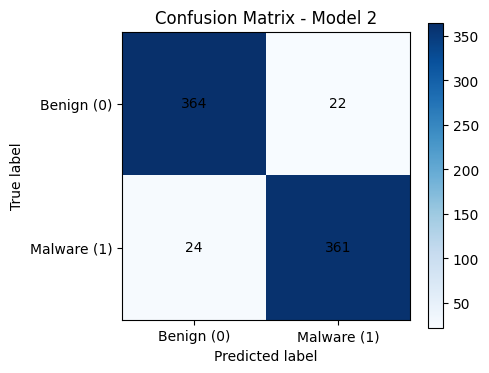

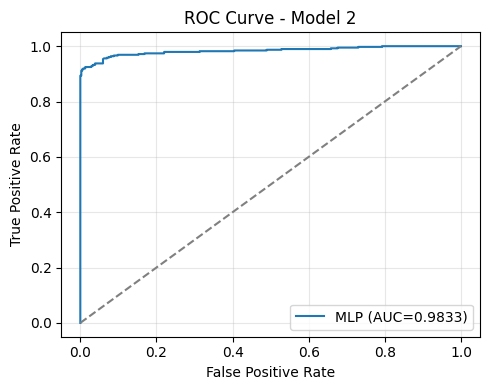

In [10]:
import matplotlib.pyplot as plt

y_pred_m2 = model2_pipe.predict(X_test_emb_m2)
y_proba_m2 = model2_pipe.predict_proba(X_test_emb_m2)[:, 1]

acc_m2 = accuracy_score(y_test_m2, y_pred_m2)
prec_m2 = precision_score(y_test_m2, y_pred_m2, zero_division=0)
rec_m2 = recall_score(y_test_m2, y_pred_m2, zero_division=0)
f1_m2 = f1_score(y_test_m2, y_pred_m2, zero_division=0)
roc_auc_m2 = roc_auc_score(y_test_m2, y_proba_m2)

print("=== Model 2: Gemini Embeddings + MLP ===")
print(f"Accuracy : {acc_m2:.4f}")
print(f"Precision: {prec_m2:.4f}")
print(f"Recall   : {rec_m2:.4f}")
print(f"F1-score : {f1_m2:.4f}")
print(f"ROC-AUC  : {roc_auc_m2:.4f}")
print()
print(classification_report(y_test_m2, y_pred_m2, zero_division=0))

cm_m2 = confusion_matrix(y_test_m2, y_pred_m2)
plt.figure(figsize=(5, 4))
plt.imshow(cm_m2, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix - Model 2")
plt.colorbar()
plt.xticks([0, 1], ["Benign (0)", "Malware (1)"])
plt.yticks([0, 1], ["Benign (0)", "Malware (1)"])
for (row_idx, col_idx), value in np.ndenumerate(cm_m2):
    plt.text(col_idx, row_idx, str(value), ha="center", va="center")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

fpr_m2, tpr_m2, _ = roc_curve(y_test_m2, y_proba_m2)
plt.figure(figsize=(5, 4))
plt.plot(fpr_m2, tpr_m2, label=f"MLP (AUC={auc(fpr_m2, tpr_m2):.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model 2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [11]:
model2_path = models_dir_m2 / "gemini_mlp_model.pkl"
result2_path = results_dir_m2 / "gemini_mlp_results.csv"
comparison_path_m2 = results_dir_m2 / "model_comparison.csv"
baseline_path_m2 = results_dir_m2 / "baseline_results.csv"

joblib.dump(
    {
        "pipeline": model2_pipe,
        "embedding_config": {
            "model": EMBED_MODEL_M2,
            "task_type": EMBED_TASK_TYPE_M2,
            "output_dimensionality": EMBED_DIM_M2,
        },
        "train_embedding_cache": str(train_emb_path_m2),
        "test_embedding_cache": str(test_emb_path_m2),
    },
    model2_path,
)

result2_row = pd.DataFrame([
    {
        "model": "Gemini Embeddings (CLASSIFICATION, dim=768) + MLP",
        "accuracy_test": acc_m2,
        "precision_test": prec_m2,
        "recall_test": rec_m2,
        "f1_test": f1_m2,
        "roc_auc_test": roc_auc_m2,
        "cv10_acc_mean": cv_scores_m2.mean(),
        "cv10_acc_std": cv_scores_m2.std(),
        "n_features": EMBED_DIM_M2,
    }
])
result2_row.to_csv(result2_path, index=False)

if baseline_path_m2.exists():
    baseline_df_m2 = pd.read_csv(baseline_path_m2)
    comparison_df_m2 = pd.concat([baseline_df_m2, result2_row], ignore_index=True, sort=False)
else:
    comparison_df_m2 = result2_row.copy()

comparison_df_m2.to_csv(comparison_path_m2, index=False)

print("Saved:")
print(" -", model2_path)
print(" -", result2_path)
print(" -", comparison_path_m2)
display(comparison_df_m2)


Saved:
 - C:\Users\Andy Ortega\Progras\Security Data Science\Lab02_SDS\models\gemini_mlp_model.pkl
 - C:\Users\Andy Ortega\Progras\Security Data Science\Lab02_SDS\results\gemini_mlp_results.csv
 - C:\Users\Andy Ortega\Progras\Security Data Science\Lab02_SDS\results\model_comparison.csv


,model,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test,cv10_acc_mean,cv10_acc_std,n_features
0,Logistic Regression (TF-IDF baseline),0.958495,0.968170,0.948052,0.958005,0.983342,0.950537,0.016732,4131
1,"Gemini Embeddings (CLASSIFICATION, dim=768) + MLP",0.940337,0.942559,0.937662,0.940104,0.983329,0.947753,0.021393,768


### Análisis comparativo de modelos

Como se observa en la tabla comparativa, el Modelo 1 (TF-IDF + Logistic Regression) obtuvo mejores resultados globales que el Modelo 2 (Gemini Embeddings + MLP) en métricas de clasificación con umbral fijo: accuracy (0.9585 vs 0.9403), precision (0.9682 vs 0.9426), recall (0.9481 vs 0.9377) y F1-score (0.9580 vs 0.9401). Además, en validación cruzada de 10 folds, el Modelo 1 también presentó una media ligeramente mayor (0.9505 vs 0.9478) y menor desviación estándar (0.0167 vs 0.0214), lo que sugiere mayor estabilidad.

En el contexto de detección de malware, la métrica más crítica suele ser el recall de la clase malware, porque un falso negativo implica no detectar una muestra maliciosa. Bajo ese criterio, el Modelo 1 también se comporta mejor (recall más alto), por lo que reduce más los casos de malware que pasan desapercibidos. Asimismo, su mayor precision indica menos falsos positivos, lo cual mejora la utilidad práctica del sistema al generar menos alertas incorrectas.

Aunque ambos modelos tienen un ROC-AUC muy similar (≈ 0.9833), lo que indica buena capacidad de separación entre clases, en esta implementación el Modelo 1 ofrece mejor desempeño operativo para clasificación final. Por ello, se concluye que el modelo que detectó mejor el malware en este laboratorio fue TF-IDF + Logistic Regression, ya que combina mejor rendimiento global, mayor sensibilidad a malware y mayor consistencia entre particiones de validación.